In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from broadcasting.results import load_run, list_runs

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

RESULTS_DIR = Path("results")

SWEEP_LABELS = {
    "p": "Depolarizing probability p",
    "tau": "Idle delay τ (dt)",
}


def latest_run():
    files = sorted(RESULTS_DIR.glob("run_*.json"))
    if not files:
        raise FileNotFoundError("No run files found in results/")
    return load_run(files[-1])


def get_sweep(run):
    """Return (axis, values, xlabel, xlim) for a run's sweep axis."""
    sweep = run.get("sweep", {}) or {}
    axis = sweep.get("axis", "p")
    values = np.array(sweep.get("values", []), dtype=float)
    xlabel = SWEEP_LABELS.get(axis, axis)
    if axis == "p":
        xlim = (0.0, 1.0)
    elif values.size:
        xlim = (float(values.min()), float(values.max()))
    else:
        xlim = None
    return axis, values, xlabel, xlim


def get_p_list(run):
    """Backwards-compatible accessor; raises if run is not a p-sweep."""
    axis, values, _, _ = get_sweep(run)
    if axis != "p":
        raise KeyError(
            f"Run {run['filename']} has sweep axis {axis!r}, not 'p'."
        )
    return values


runs = list_runs(RESULTS_DIR)
print(f"Found {len(runs)} run(s) in {RESULTS_DIR}/\n")
for i, r in enumerate(runs):
    qec_str = "QEC" if r.get("use_qec") else "no-QEC"
    backend = r.get("backend", "?")
    opt = r.get("optimization_level")
    opt_str = f" opt={opt}" if opt is not None else ""
    axis, values, _, _ = get_sweep(r)
    n_pts = len(values)
    print(f"  [{i}] {r['filename']}: M={r['M']}, N={r['N']}, {qec_str}, "
          f"{r['experiment_type']}/{backend}{opt_str}, "
          f"{n_pts} {axis}-points")


Found 43 run(s) in results/

  [0] run_20260408_160814.json: M=1, N=2, no-QEC, hardware/ibm_kingston opt=3, 41 tau-points
  [1] run_20260408_161340.json: M=1, N=3, no-QEC, hardware/ibm_marrakesh opt=3, 41 tau-points
  [2] run_20260408_161902.json: M=1, N=4, no-QEC, hardware/ibm_marrakesh opt=3, 41 tau-points
  [3] run_20260408_162212.json: M=2, N=2, no-QEC, hardware/ibm_marrakesh opt=3, 41 tau-points
  [4] run_20260408_162440.json: M=2, N=3, no-QEC, hardware/ibm_marrakesh opt=3, 41 tau-points
  [5] run_20260408_162906.json: M=2, N=4, no-QEC, hardware/ibm_fez opt=3, 41 tau-points
  [6] run_20260408_163129.json: M=3, N=2, no-QEC, hardware/ibm_marrakesh opt=3, 41 tau-points
  [7] run_20260408_170544.json: M=1, N=2, no-QEC, hardware/ibm_fez opt=3, 41 tau-points
  [8] run_20260409_142040.json: M=1, N=2, no-QEC, simulation/aer_exact, 50 p-points
  [9] run_20260409_142625.json: M=1, N=2, QEC, simulation/aer_sampling, 50 p-points
  [10] run_20260416_100341.json: M=1, N=2, QEC, simulation/aer_s

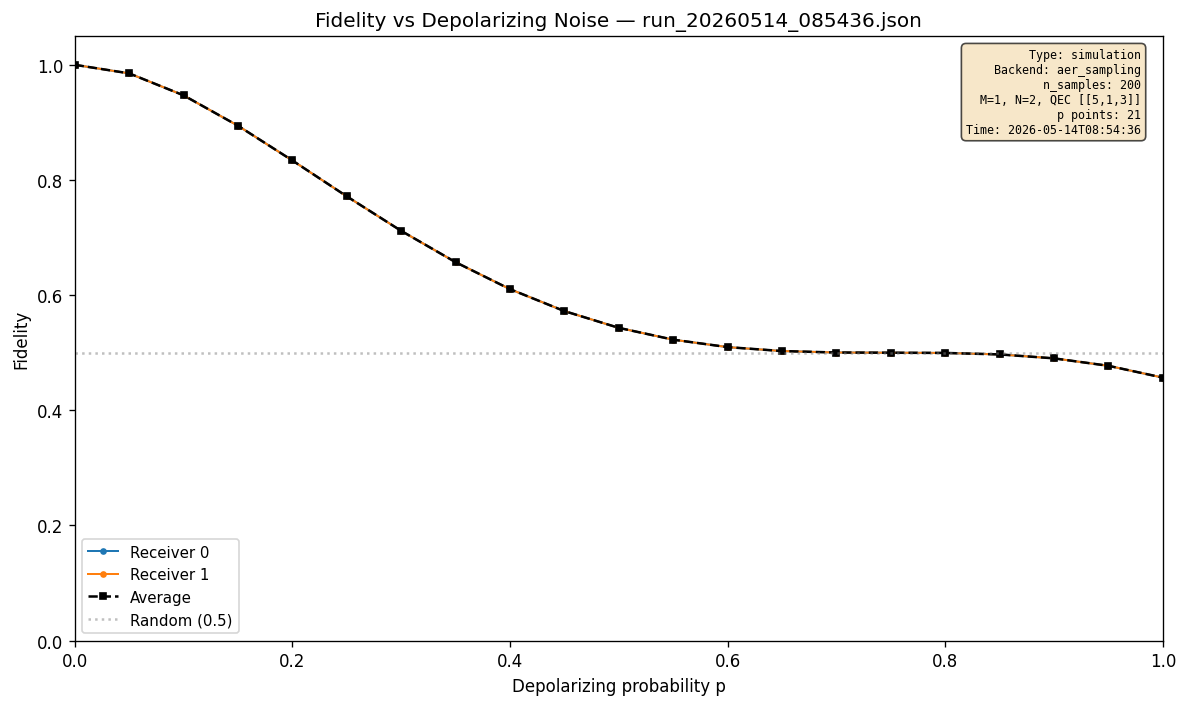

In [6]:
# --- Latest run: fidelity vs sweep axis (p or tau) ---

run = latest_run()
N = run["N"]
fids = np.array(run["fidelities"])  # shape (n_sweep, N)
axis, x_arr, xlabel, xlim = get_sweep(run)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i in range(N):
    ax.plot(x_arr, fids[:, i], "-o", color=colors[i % len(colors)],
            markersize=3, linewidth=1.2, label=f"Receiver {i}")

ax.plot(x_arr, fids.mean(axis=1), "s--", color="black",
        markersize=4, linewidth=1.5, label="Average")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (0.5)")

ax.set_xlabel(xlabel)
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.05)
if xlim is not None:
    ax.set_xlim(*xlim)
ax.legend(loc="best", fontsize=9)

# Metadata annotation
qec_str = "QEC [[5,1,3]]" if run.get("use_qec") else "No QEC"
backend = run.get("backend", "?")
opt = run.get("optimization_level")
meta_lines = [
    f"Type: {run['experiment_type']}",
    f"Backend: {backend}" + (f" (opt={opt})" if opt is not None else ""),
    f"M={run['M']}, N={N}, {qec_str}",
    f"{axis} points: {len(x_arr)}",
    f"Time: {run.get('timestamp', '')[:19]}",
]
if run.get("n_samples"):
    meta_lines.insert(2, f"n_samples: {run['n_samples']}")
if run.get("shots"):
    meta_lines.insert(2, f"shots: {run['shots']}")
ax.text(0.98, 0.98, "\n".join(meta_lines), transform=ax.transAxes,
        fontsize=7, va="top", ha="right", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7))

axis_title = "Depolarizing Noise" if axis == "p" else "Idle Delay τ"
ax.set_title(f"Fidelity vs {axis_title} — {run['filename']}")
plt.tight_layout()
plt.show()


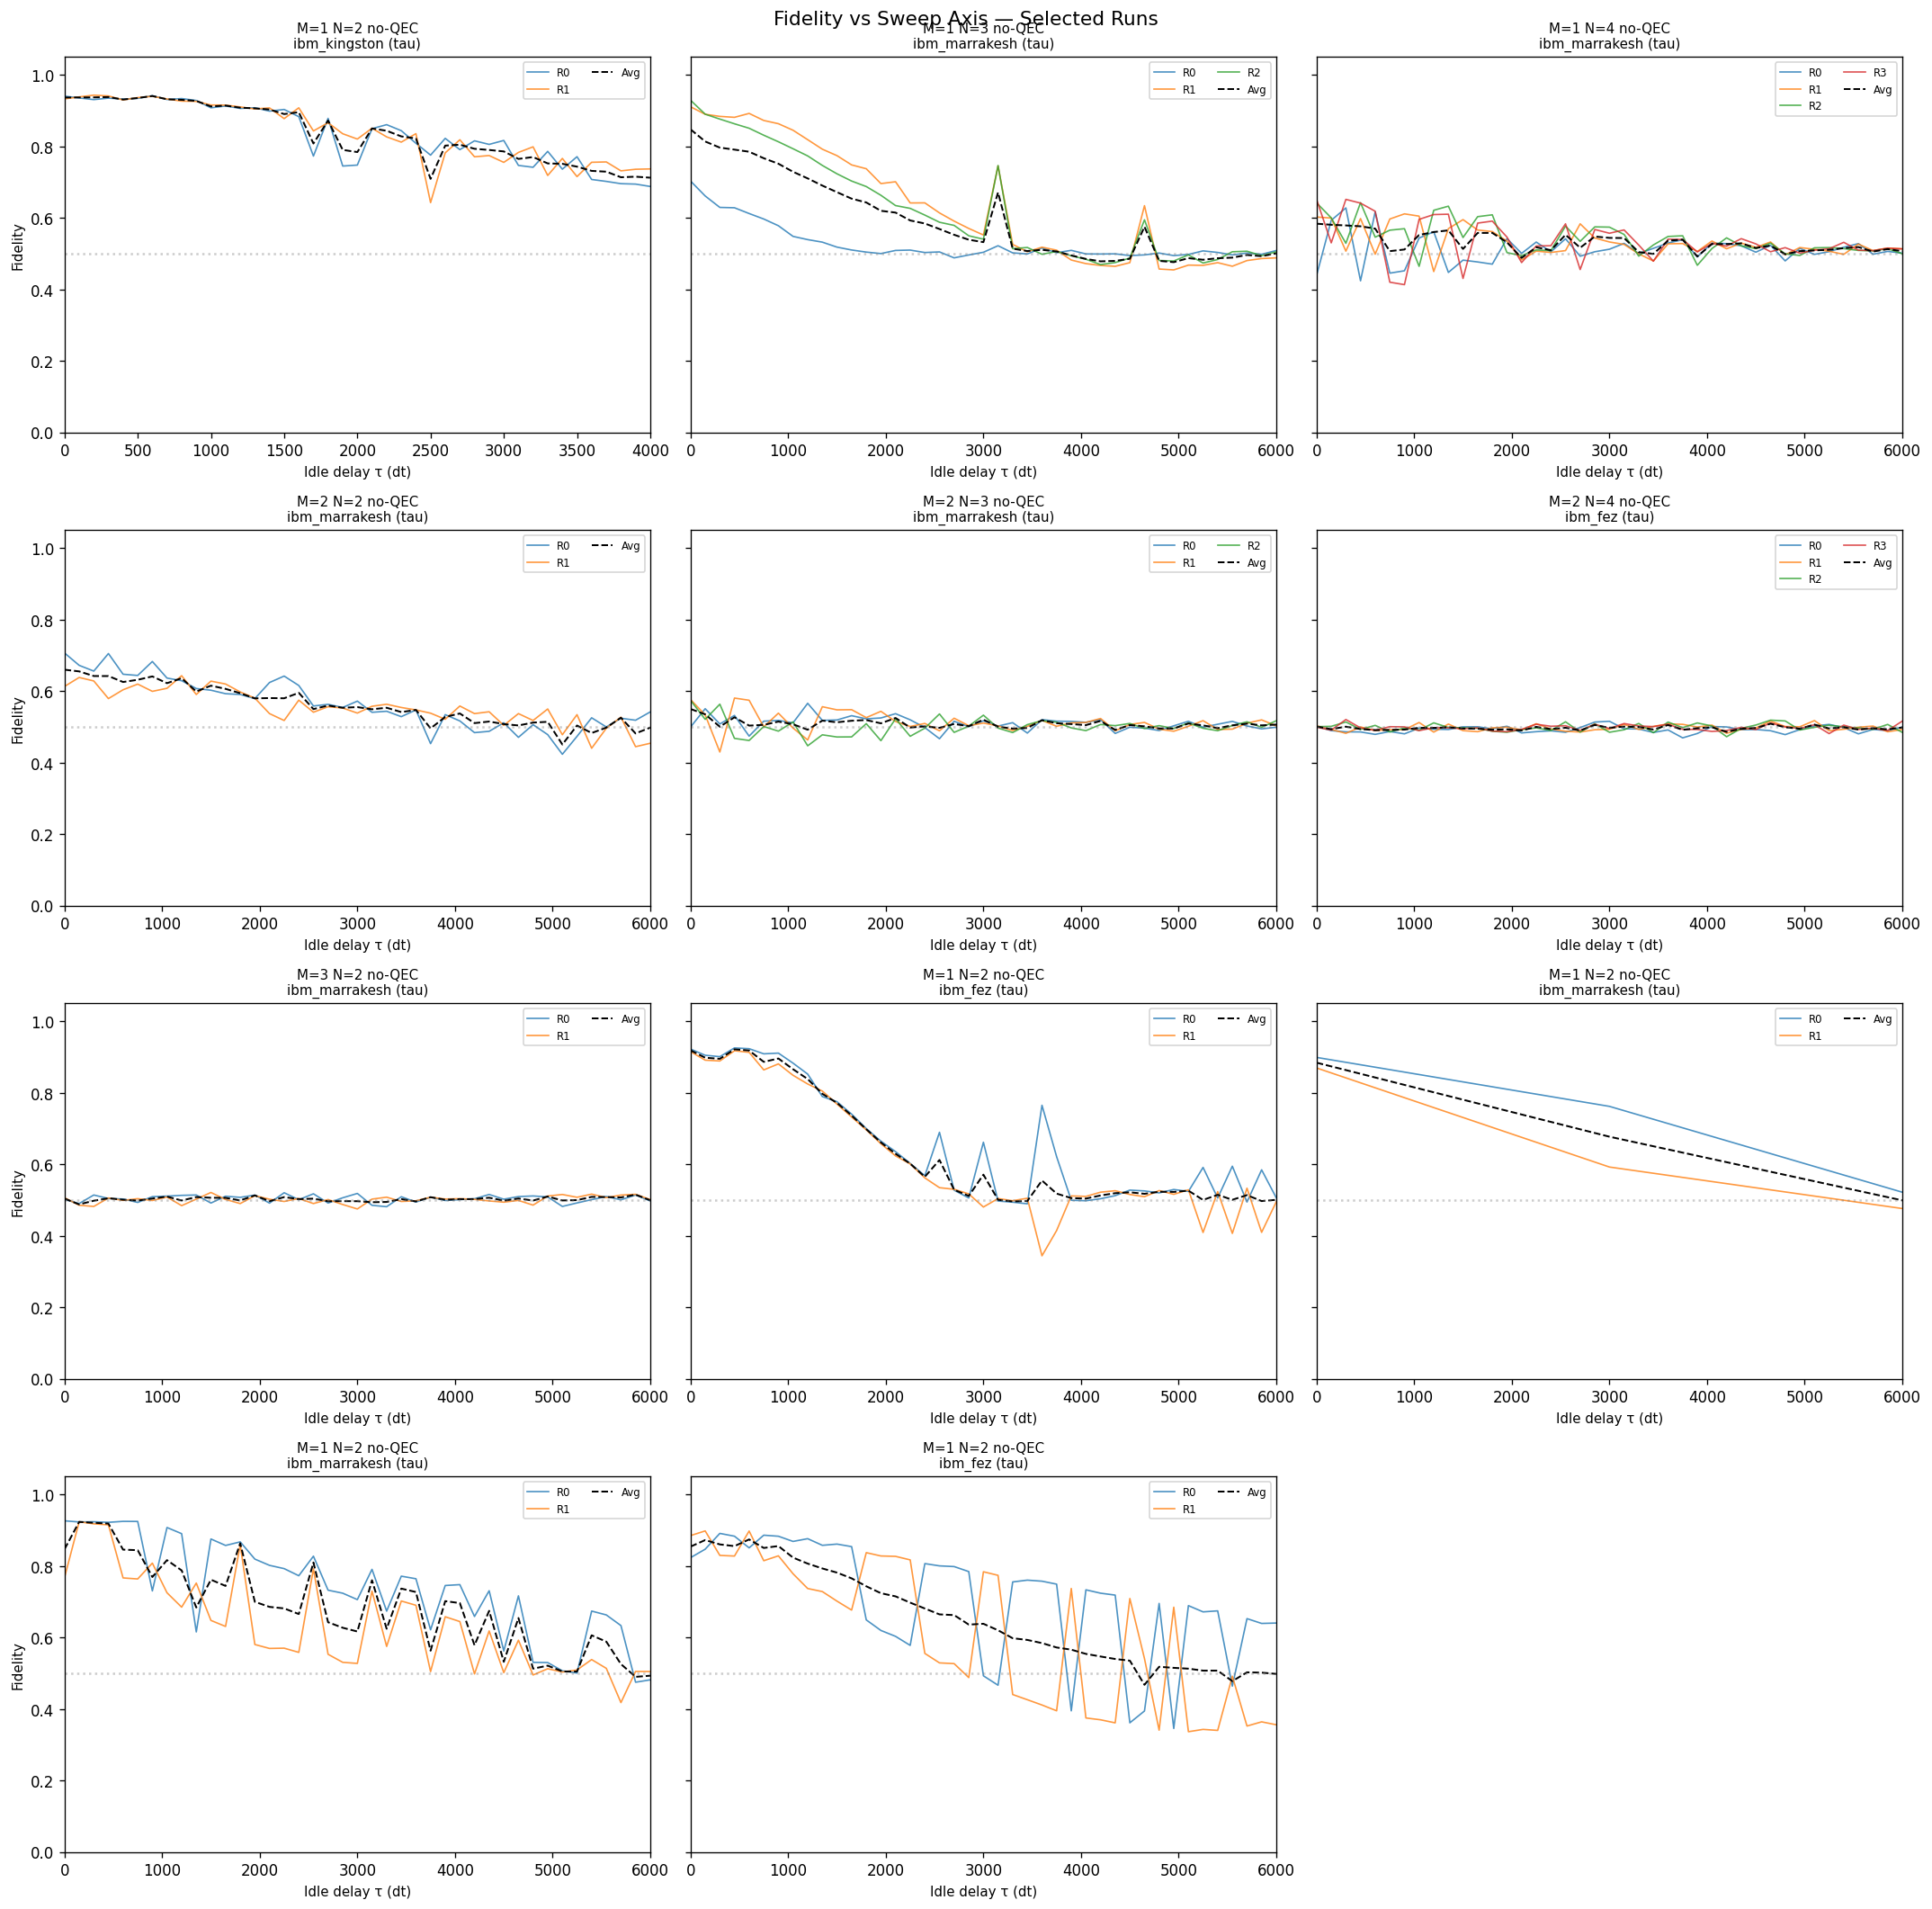


11 run(s) shown:
  [0] run_20260408_160814.json  M=1 N=2 no-QEC  hardware/ibm_kingston (tau-sweep)
  [1] run_20260408_161340.json  M=1 N=3 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [2] run_20260408_161902.json  M=1 N=4 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [3] run_20260408_162212.json  M=2 N=2 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [4] run_20260408_162440.json  M=2 N=3 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [5] run_20260408_162906.json  M=2 N=4 no-QEC  hardware/ibm_fez (tau-sweep)
  [6] run_20260408_163129.json  M=3 N=2 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [7] run_20260408_170544.json  M=1 N=2 no-QEC  hardware/ibm_fez (tau-sweep)
  [8] run_20260513_141704.json  M=1 N=2 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [9] run_20260513_144130.json  M=1 N=2 no-QEC  hardware/ibm_marrakesh (tau-sweep)
  [10] run_20260513_150433.json  M=1 N=2 no-QEC  hardware/ibm_fez (tau-sweep)


In [7]:
# --- Multi-run comparison: fidelity vs sweep axis ---
# Customize the filter below to select which runs to compare.
# Examples:
#   selected = runs                                              # all runs
#   selected = [runs[0], runs[2]]                                # by index
#   selected = [r for r in runs if r["use_qec"]]                 # QEC only
#   selected = [r for r in runs if r["M"] == 1]                  # M=1 only
selected = [r for r in runs if r["experiment_type"] == "hardware"]
#   selected = [r for r in runs if r.get("sweep", {}).get("axis") == "tau"]

# selected = [r for r in runs if r["use_qec"]]

if not selected:
    print("No runs matched the selection criteria.")
else:
    n_runs = len(selected)
    ncols = min(n_runs, 3)
    nrows = int(np.ceil(n_runs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    for idx, run in enumerate(selected):
        ax = axes[idx // ncols][idx % ncols]
        axis, x_arr, xlabel, xlim = get_sweep(run)
        if x_arr.size == 0:
            ax.text(0.5, 0.5, "No sweep values", ha="center",
                    va="center", transform=ax.transAxes)
            continue

        fids = np.array(run["fidelities"])  # (n_sweep, N)
        N = run["N"]
        colors = plt.cm.tab10.colors

        for i in range(N):
            ax.plot(x_arr, fids[:, i], "-", color=colors[i % len(colors)],
                    linewidth=1, alpha=0.8, label=f"R{i}")
        ax.plot(x_arr, fids.mean(axis=1), "k--", linewidth=1.2, label="Avg")
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        if xlim is not None:
            ax.set_xlim(*xlim)
        ax.set_xlabel(xlabel, fontsize=9)
        if idx % ncols == 0:
            ax.set_ylabel("Fidelity", fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=2)

        qec_tag = "QEC" if run.get("use_qec") else "no-QEC"
        ax.set_title(f"M={run['M']} N={N} {qec_tag}\n{run['backend']} ({axis})",
                     fontsize=9)

    for idx in range(n_runs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Fidelity vs Sweep Axis — Selected Runs", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n{n_runs} run(s) shown:")
    for i, r in enumerate(selected):
        axis = r.get("sweep", {}).get("axis", "?")
        print(f"  [{i}] {r['filename']}  M={r['M']} N={r['N']} "
              f"{'QEC' if r.get('use_qec') else 'no-QEC'}  "
              f"{r['experiment_type']}/{r['backend']} ({axis}-sweep)")


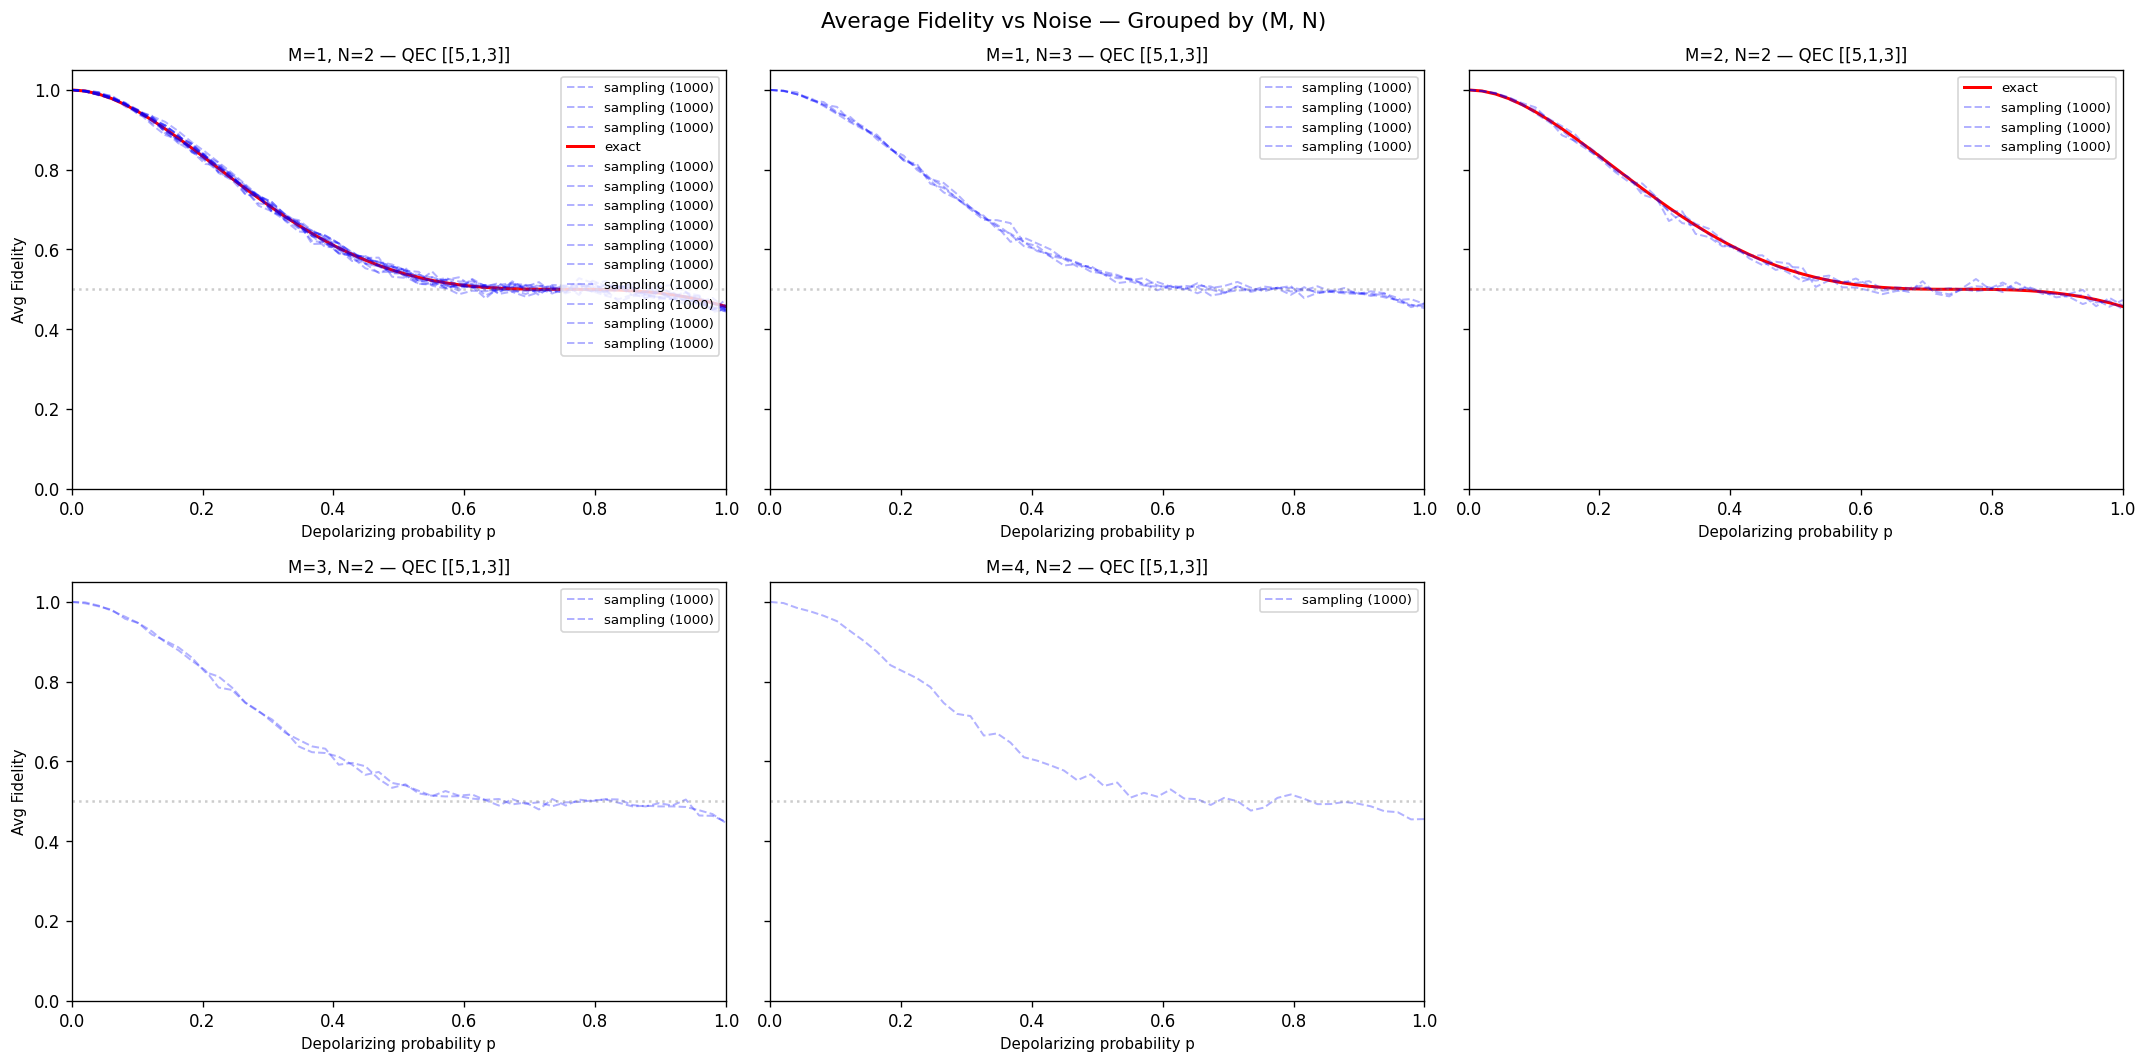

In [ ]:
# --- Exact vs sampling overlay: same M, N across simulation runs ---
# Exact runs: red solid line, alpha=1 (one per panel)
# Sampling runs: blue dashed lines, alpha=0.3 (all shown)

from collections import defaultdict

groups = defaultdict(list)
for r in runs:
    if (r.get("experiment_type") == "simulation"
            and r["use_qec"] and r["N"] >= 2):
        groups[(r["M"], r["N"])].append(r)

pairs = {k: v for k, v in groups.items() if len(v) >= 1}

if not pairs:
    print("No runs to compare.")
else:
    n_groups = len(pairs)
    ncols = min(n_groups, 3)
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    for gidx, ((M, N), group_runs) in enumerate(sorted(pairs.items())):
        ax = axes[gidx // ncols][gidx % ncols]

        exact_plotted = False
        for run in group_runs:
            if run.get("sweep", {}).get("axis") != "p":
                continue
            p_arr = get_p_list(run)
            backend = run.get("backend", "")
            avg = np.array(run["fidelities"]).mean(axis=1)

            if backend == "aer_exact":
                if exact_plotted:
                    continue
                ax.plot(p_arr, avg, linestyle="-", color="red",
                        linewidth=1.8, alpha=1.0, label="exact")
                exact_plotted = True
            elif backend == "aer_sampling":
                n_samples = run.get("n_samples", "?")
                ax.plot(p_arr, avg, linestyle="--", color="blue",
                        linewidth=1.2, alpha=0.3,
                        label=f"sampling ({n_samples})")
            else:
                ax.plot(p_arr, avg, linestyle=":", color="gray",
                        linewidth=1.0, alpha=0.6, label=backend)

        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Depolarizing probability p", fontsize=9)
        if gidx % ncols == 0:
            ax.set_ylabel("Avg Fidelity", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_title(f"M={M}, N={N} — QEC [[5,1,3]]", fontsize=10)

    for idx in range(n_groups, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Average Fidelity vs Noise — Grouped by (M, N)", fontsize=13)
    plt.tight_layout()
    plt.show()
